# Survival Analysis

Dengue federated analysis workshop.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ISARICResearch/Dissemination/blob/main/workshops/federated%20analytics/FederatedAnalysis_Project/notebooks/04_survival_analysis.ipynb)
<!-- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/88ssarmiento/federated-analytics-workshop-dengue/blob/master/notebooks/04_survival_analysis.ipynb) -->

## Introduction

Survival analysis studies how long it takes for an event of interest, such as death, to occur, rather than only whether it occurs. It is usually carried out with Kaplan-Meier curves, which estimate the probability of remaining event-free over time, and with Cox regression, which estimates hazard ratios describing how each variable increases or decreases the risk of the event. It helps understand how quickly a disease can progress to a severe outcome and which factors are linked to a faster progression, supporting the prioritization of care during an outbreak.

This notebook walks through the full process of calculating and comparing survival estimates using the workshop's dummy dengue dataset.

## Objective

Compare the survival probabilities and hazard ratios obtained with the centralized and federated approaches, to evaluate whether they match and identify where they diverge. The workshop uses a dummy dengue dataset from 5 health institutions.

## Table of Contents

```
1. Setup
    1.1. Environment detection
    1.2. Install dependencies
    1.3. Get project files
    1.4. Imports
    1.5. Load data
2. Data Preparation
    2.1. Drop unused columns
    2.2. Drop rows with missing key values
    2.3. Follow-up time and event
    2.4. Age groups
3. Considerations
4. Centralized Approach
    4.1. Overall survival curve
    4.2. Survival by age group
    4.3. Cox regression
5. Federated Approach
    5.1. Split the data by institution
    5.2. Per-site survival probabilities
    5.3. Aggregated survival probabilities
    5.4. Per-site Cox models
    5.5. Aggregated hazard ratios
6. Comparison
    6.1. Survival probabilities
    6.2. Hazard ratios
7. Conclusions
```

## 1. Setup

Prepare everything the notebook needs before starting the analysis.

### 1.1. Environment detection

Check whether this notebook is running on Google Colab or on a local computer.

In [1]:
import sys

# True on Google Colab, False on a local computer
IN_COLAB = "google.colab" in sys.modules

### 1.2. Install dependencies

Install any extra packages this notebook needs. This step only runs on Google Colab. On a local computer, the packages are already installed.

In [2]:
# if IN_COLAB:
#     %pip install -q <package>

### 1.3. Get project files

Get the project's data and code. On Google Colab, only the project's folder is downloaded first from the repository where it's published; on a local computer, they're already available next to this notebook.

In [3]:
from pathlib import Path

# Repository the project is downloaded from on Google Colab (keep only one uncommented)
REPO_URL, PROJECT_PATH = "https://github.com/ISARICResearch/Dissemination.git", "workshops/federated analytics/FederatedAnalysis_Project"
# REPO_URL, PROJECT_PATH = "https://github.com/88ssarmiento/federated-analytics-workshop-dengue.git", ""
REPO_NAME = Path(REPO_URL).stem

if IN_COLAB:
    # Download only this project's folder, not the whole repository
    project_dir = Path(REPO_NAME) / PROJECT_PATH
    if not project_dir.exists():
        if PROJECT_PATH:
            !git clone --depth 1 --filter=blob:none --sparse {REPO_URL}
            !git -C {REPO_NAME} sparse-checkout set "{PROJECT_PATH}"
        else:
            !git clone --depth 1 {REPO_URL}
else:
    # This notebook already lives inside the project
    project_dir = Path("..")

# Make the project's own code importable (e.g. `analysis_lib`)
sys.path.insert(0, str(project_dir))

data_dir = project_dir / "data"
data_file = data_dir / "dummy_data.parquet"
dictionary_file = data_dir / "dummy_data_dictionary.json"

### 1.4. Imports

Load the Python libraries used in this notebook.

In [4]:
# Standard library
import json

# Third-party
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.duration.survfunc import SurvfuncRight

# Project
from analysis_lib.survival_analysis import (
    format_hazard_ratio_comparison,
    format_survival_comparison,
    plot_survival_curves,
    pool_hazard_ratio,
    pool_survival,
    survival_table,
)

### 1.5. Load data

Read the example data.

In [5]:
# Load the full example dataset
df = pd.read_parquet(data_file)

# Load the data dictionary that describes each column
with open(dictionary_file, encoding="utf-8") as f:
    data_dictionary = json.load(f)

## 2. Data Preparation

Prepare the dataset for the survival analysis: keep only the relevant columns, remove rows that can't be used, compute each patient's follow-up time and whether they died, and group patients by age.

### 2.1. Drop unused columns

Keep only the columns needed for the survival analysis: the institution, the symptom onset and death dates (to compute each patient's follow-up time), `age` (to define the groups being compared) and `outcome`. Symptoms, exams and the remaining dates and medical care columns aren't used in this notebook.

In [6]:
# Columns used in the survival analysis
columns = ["institution", "symptom_onset_date", "death_date", "age", "outcome"]
df = df[columns]

### 2.2. Drop rows with missing key values

Remove records that can't be used in the analysis: with no known outcome, institution, symptom onset date or age, or patients who died with no known death date, since their follow-up time can't be computed.

This dataset doesn't have any, but the check is included as a standard data-cleaning step.

In [7]:
df = df.dropna(subset=["outcome", "institution", "symptom_onset_date", "age"])

# A death with no known date has no known follow-up time
df = df[~((df["outcome"] == "Dead") & df["death_date"].isna())]

### 2.3. Follow-up time and event

Survival analysis needs two values for each patient:
- `time` is the number of days from symptom onset until death, or until the end of follow-up for patients who didn't die.
- `event` is 1 if the patient died during follow-up and 0 otherwise.

**Follow-up period.** The dataset records the date of death for patients who died, but not the date survivors were last seen. Their `outcome` only says they were alive at the end of their care. To give them a follow-up time, every patient is followed for a fixed period of 30 days from symptom onset, and patients recorded as `"Alive"` are assumed to be alive on day 30. These patients are **censored**, meaning it's only known that they survived at least until that day, not what happened afterwards.

**Why 30 days.** The follow-up period must be one in which it's reasonable to assume that survivors were still alive at its end. Dengue is an acute illness that resolves within a few weeks, so a patient who survived it was very likely still alive 30 days after symptom onset. A longer period would assume every survivor stayed alive for months, with no data to support it. In this dataset, 96 of the 98 deaths occur within those 30 days.

**Deaths after day 30.** The other 2 deaths, at 46 and 100 days, are censored on day 30, since those patients were still alive at the end of follow-up. Both had their symptom onset recorded more than 40 days before their consultation, while 95% of patients consulted within 8 days, so their onset date was probably recorded incorrectly.

In [8]:
# Follow-up period, in days from symptom onset
follow_up_days = 30

days_to_death = (df["death_date"] - df["symptom_onset_date"]).dt.days
died_during_follow_up = (df["outcome"] == "Dead") & (days_to_death <= follow_up_days)

# Deaths during follow-up keep their time until death; everyone else is censored at the end of follow-up
df["time"] = days_to_death.where(died_during_follow_up, follow_up_days).astype(int)
df["event"] = died_during_follow_up.astype(int)

### 2.4. Age groups

Survival curves and the Cox model compare groups of patients defined at the start of follow-up, so the variable that defines them must already be known on the day of symptom onset. Age and sex meet this condition, unlike symptoms such as shock, which appear during the illness. Age is used because it shows a clear difference in mortality, while the association of sex with death was inconclusive in `03_odds_ratios.ipynb`.

`age` is split into two groups: patients under 60 and patients aged 60 or over. Sixty years is a common threshold for older adults, and in this dataset it separates two groups with clearly different mortality during follow-up: 31 of 1,194 patients aged 60 or over died (2.6%), compared with 65 of 9,090 patients under 60 (0.7%).

The new column `age_60_plus` is 1 for patients aged 60 or over and 0 for those under 60, so patients under 60 are the reference group.

In [9]:
# 1 = aged 60 or over, 0 = under 60 (reference group)
df["age_60_plus"] = (df["age"] >= 60).astype(int)

## 3. Considerations

A few decisions apply to both the centralized and federated approaches, explained here once instead of repeating them in every section:

- **The analysis uses the whole dataset, with no train/test split.** As in `03_odds_ratios.ipynb`, this is an explanatory analysis, not a predictive one: the goal is to describe how survival differs between age groups in this data, not to predict the outcome of new patients. A train/test split is only needed to measure how well a model predicts, so it doesn't apply here.
- **Only one variable, age, is analysed.** The same age groups (section 2.4) are used for the survival curves and for the Cox model, so both describe the same comparison.

## 4. Centralized Approach

Compute the survival curves and the hazard ratio over the whole dataset, as if all institutions shared their data directly.

### 4.1. Overall survival curve

The Kaplan-Meier curve shows the probability that a patient is still alive a given number of days after symptom onset. It starts at 100% on day 0 and drops a step on each day on which at least one patient dies. Each step is calculated only among the patients still being followed on that day, which is how censored patients (section 2.3) contribute: they count as survivors for every day they were followed.

The curve below includes all patients together. Since only about 1% of patients died, the vertical axis starts at 98.5% instead of 0%, so that the drop is visible.

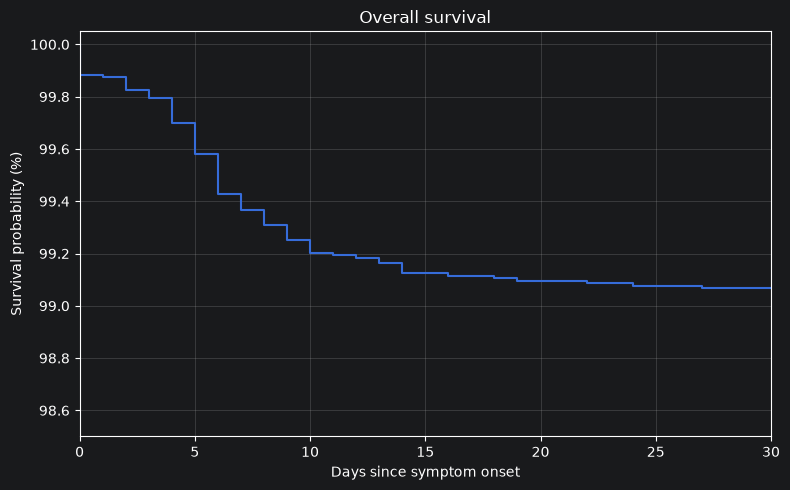

In [10]:
# Kaplan-Meier curve for all patients
survival_overall = SurvfuncRight(df["time"], df["event"])

plot_survival_curves({"All patients": survival_overall}, follow_up_days, title="Overall survival", y_min=98.5)

Survival falls from 100% to about 99.1% by day 30. Most of the drop happens during the first two weeks after symptom onset, and the curve is almost flat afterwards: in this dataset, patients who die from dengue do so early in the illness.

### 4.2. Survival by age group

The same curve is now calculated separately for each age group (section 2.4), using only that group's patients, and both curves are drawn together. If one curve drops more than the other, patients in that group die more often or sooner.

The table below reads the curves at the end of follow-up (day 30): the number of patients, the deaths during follow-up and the probability of surviving until that day, with its 95% confidence interval (the range of values compatible with the data, as in `03_odds_ratios.ipynb`). The table also keeps the standard error of each survival probability, which the federated approach combines in section 5.3.

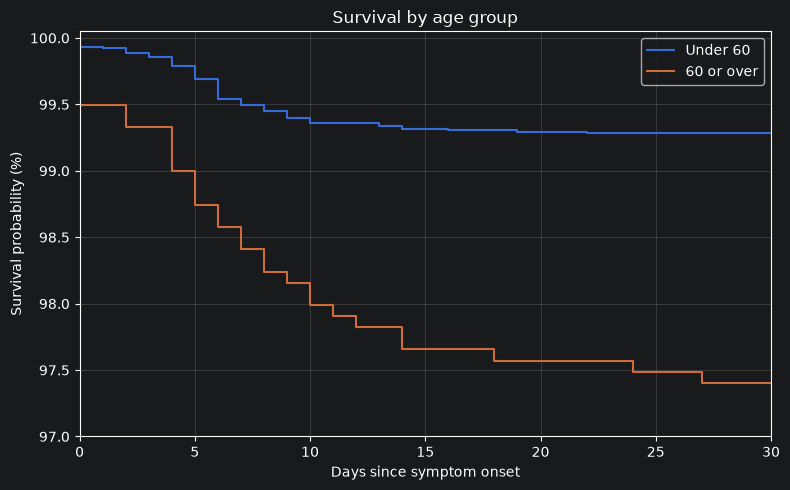

,Patients,Deaths,Survival (%),StdErr (%),CI95_low (%),CI95_high (%)
All patients,10284,96,99.07,0.09,98.88,99.25
Under 60,9090,65,99.28,0.09,99.11,99.46
60 or over,1194,31,97.40,0.46,96.50,98.31


In [11]:
# One Kaplan-Meier curve per age group
under_60 = df[df["age_60_plus"] == 0]
aged_60_plus = df[df["age_60_plus"] == 1]
survival_by_age = {
    "Under 60": SurvfuncRight(under_60["time"], under_60["event"]),
    "60 or over": SurvfuncRight(aged_60_plus["time"], aged_60_plus["event"]),
}
plot_survival_curves(survival_by_age, follow_up_days, title="Survival by age group", y_min=97)

# Survival at the end of follow-up, for all patients (section 4.1) and by age group
survival_centralized = survival_table({"All patients": survival_overall, **survival_by_age}, day=follow_up_days)
display(survival_centralized.round(2))

The curve of patients aged 60 or over drops clearly more than that of patients under 60: 97.4% of them survived until day 30, compared with 99.28% of patients under 60, and their confidence intervals don't overlap. In both groups, most of the drop happens during the first two weeks after symptom onset.

### 4.3. Cox regression

The Cox model compares the risk of death between the two age groups over the whole follow-up, and summarizes it in a single number:

- **Hazard**: the risk of dying on a given day among the patients still alive on that day.
- **Hazard ratio**: how many times higher the hazard is in patients aged 60 or over than in patients under 60 (the reference group). It's read like the odds ratio in `03_odds_ratios.ipynb`: 1 means no difference, above 1 a higher risk and below 1 a lower risk. Its 95% confidence interval and p-value are read the same way too.

The model estimates a **coefficient**, and the hazard ratio is its exponential, as with the odds ratio. The coefficient and its **standard error** are what each institution shares in the federated approach (section 5).

**Assumption: proportional hazards.** The model summarizes the whole follow-up in a single hazard ratio, so it assumes that the difference in risk between the two groups stays the same over time: if patients aged 60 or over have three times the risk of dying on the first day, they also have three times the risk on day 10 and on day 25. The model always returns a hazard ratio, but if this assumption doesn't hold, that number is misleading, because it averages periods with different risks. For example, a much higher risk during the first week and no difference afterwards would give an intermediate value that describes neither period. A simple way to check it is to look at the survival curves of both groups (section 4.2): if the assumption holds, the curves separate and stay separated, without crossing or coming back together.

This is the same function the federated approach in section 5 will call once per institution.

In [12]:
def compute_hazard_ratio(df: pd.DataFrame, predictor: str) -> pd.DataFrame:
    """Fit a univariate Cox model and collect the predictor's hazard ratio.

    Args:
        df: Dataset with the follow-up `time` and `event` columns.
        predictor: Name of the 0/1 column defining the groups compared.

    Returns:
        One row with the coefficient, standard error, hazard ratio, 95% CI and p-value.
    """
    # Risk of death during follow-up explained by the predictor. Several deaths
    # on the same day are handled with Efron's method. BFGS finds the coefficient
    # reliably even when it's large (plain Newton steps can overshoot)
    model = smf.phreg(f"time ~ {predictor}", data=df, status=df["event"], ties="efron").fit(method="bfgs", gtol=1e-8)

    # The model has a single predictor, so each result holds one value.
    # exp() turns the coefficient and its CI into the hazard ratio and its CI
    ci_low, ci_high = np.exp(model.conf_int()[0])

    return pd.DataFrame({
        predictor: {
            "Coefficient": model.params[0],
            "StdErr": model.bse[0],
            "HazardRatio": np.exp(model.params[0]),
            "CI95_low": ci_low,
            "CI95_high": ci_high,
            "p-value": model.pvalues[0],
        }
    }).T

In [13]:
# Apply the function to the whole dataset
hazard_ratio_centralized = compute_hazard_ratio(df, predictor="age_60_plus")
display(hazard_ratio_centralized.round(3))

,Coefficient,StdErr,HazardRatio,CI95_low,CI95_high,p-value
age_60_plus,1.299,0.218,3.665,2.389,5.621,0.0


Patients aged 60 or over have a hazard ratio of 3.66 (95% CI 2.39 to 5.62): on any day of follow-up, among the patients still alive, their risk of dying is about 3.7 times that of patients under 60. The p-value is shown as 0.0 because it's rounded to 3 decimals; its actual value is below 0.001, so the difference is very unlikely to be due to chance.

The proportional hazards assumption is reasonable here: the curves in section 4.2 separate during the first two weeks and then stay separated until day 30, without crossing or coming back together.

## 5. Federated Approach

Compute the survival curves and the hazard ratio within each institution, then combine them without sharing individual records.

### 5.1. Split the data by institution

Separate the dataset into one subset per institution. Each subset simulates the data a single hospital holds locally: it's the only data that hospital can use to calculate its own survival curves and Cox model, and it never leaves the hospital. What each hospital shares later isn't this data, but the results calculated from it.

In [14]:
# Simulate each institution's local data: the records only that institution holds
site_data = {site: df.loc[df["institution"] == site] for site in sorted(df["institution"].unique())}

### 5.2. Per-site survival probabilities

Each institution calculates the survival curves of its own patients, all together and by age group, as in sections 4.1 and 4.2, and summarizes them at the end of follow-up (day 30). This summary is what each institution shares with the server: the number of patients and deaths, the survival probability and its standard error. The server uses the number of patients to weight each institution's survival probability when combining them, and the standard errors to calculate the confidence interval of the combined probability (section 5.3).

Each institution shares only its summary on day 30, not its whole survival curve: the steps of a curve show how many patients died on each day, sometimes a single one, which institutions usually don't share.

In [15]:
# Each institution calculates its own survival curves and summarizes them on day 30
local_survival = {}
for site, data in site_data.items():
    under_60 = data[data["age_60_plus"] == 0]
    aged_60_plus = data[data["age_60_plus"] == 1]
    curves = {
        "All patients": SurvfuncRight(data["time"], data["event"]),
        "Under 60": SurvfuncRight(under_60["time"], under_60["event"]),
        "60 or over": SurvfuncRight(aged_60_plus["time"], aged_60_plus["event"]),
    }
    local_survival[site] = survival_table(curves, day=follow_up_days)

# What the server receives: one summary table per institution
shared_survival = pd.concat(local_survival, names=["site", "group"])
display(shared_survival.round(2))

Patients  Deaths  Survival (%)  StdErr (%)  CI95_low (%)  \
site group                                                                    
H1   All patients      1233      20         98.38        0.36         97.67   
     Under 60          1148      16         98.61        0.35         97.93   
     60 or over          85       4         95.29        2.30         90.79   
H2   All patients      5543      25         99.55        0.09         99.37   
     Under 60          4825      14         99.71        0.08         99.56   
     60 or over         718      11         98.47        0.46         97.57   
H3   All patients      2464      17         99.31        0.17         98.98   
     Under 60          2162      11         99.49        0.15         99.19   
     60 or over         302       6         98.01        0.80         96.44   
H4   All patients       294      17         94.22        1.36         91.55   
     Under 60           282      13         95.39        1.25         92.94   
     60 or over          12       4         66.67       13.61         39.99   
H5   All patients       750      17         97.73        0.54         96.67   
     Under 60           673      11         98.37        0.49         97.41   
     60 or over          77       6         92.21        3.05         86.22   

                   CI95_high (%)  
site group                        
H1   All patients          99.08  
     Under 60              99.28  
     60 or over            99.80  
H2   All patients          99.73  
     Under 60              99.86  
     60 or over            99.37  
H3   All patients          99.64  
     Under 60              99.79  
     60 or over            99.59  
H4   All patients          96.89  
     Under 60              97.84  
     60 or over            93.34  
H5   All patients          98.80  
     Under 60              99.32  
     60 or over            98.19

Survival differs between institutions, from 99.55% of all patients at H2 to 94.22% at H4, but at every institution patients aged 60 or over survive less than those under 60. H4 has only 12 patients aged 60 or over, 4 of whom died, so its survival for that group (66.67%) is very imprecise, as its large standard error shows.

### 5.3. Aggregated survival probabilities

The server combines the summaries shared by the institutions, separately for all patients and for each age group, in three steps:

1. **Combined survival**: the average of the institutions' survival probabilities, weighted by their number of patients: $S = \sum_i n_i S_i / N$, where $n_i$ is institution $i$'s number of patients, $S_i$ its survival probability and $N$ the total number of patients.
2. **Combined standard error**: calculated from each institution's standard error $SE_i$ with the same weights: $SE = \sqrt{\sum_i (n_i / N)^2 \, SE_i^2}$.
3. **95% confidence interval**: $S \pm 1.96 \cdot SE$, as in section 4.2.

**Why weight by the number of patients.** The survival probability on day 30 is the proportion of patients still alive on that day. To obtain that proportion for all institutions together, each institution must count according to how many patients it contributes. Since nobody in this dataset is censored before day 30, this weighted average gives exactly the proportion of survivors among all patients; with censoring earlier in follow-up, it would only be an approximation. The hazard ratio is combined differently (section 5.5), because it isn't a proportion of patients.

In [16]:
# The server combines each group's summaries across institutions
pooled = {}
for group in shared_survival.index.unique(level="group"):
    pooled[group] = pool_survival(shared_survival.xs(group, level="group"))

survival_federated = pd.DataFrame.from_dict(pooled, orient="index")
display(survival_federated.round(2))

,Patients,Deaths,Survival (%),StdErr (%),CI95_low (%),CI95_high (%)
All patients,10284,96,99.07,0.09,98.88,99.25
Under 60,9090,65,99.28,0.09,99.11,99.46
60 or over,1194,31,97.40,0.45,96.52,98.28


The combined survival on day 30 is 99.07% for all patients, 99.28% for patients under 60 and 97.40% for those aged 60 or over, whose confidence intervals don't overlap: patients aged 60 or over survive less.

### 5.4. Per-site Cox models

Each institution fits its own Cox model with its own patients, using the same function as section 4.3. It shares with the server the coefficient and its standard error, which the server combines in section 5.5; the hazard ratio, its confidence interval and its p-value are shown so each institution's result can be read.

Every institution has deaths in both age groups (between 4 and 11 among patients aged 60 or over), so the model can be estimated at all of them (unlike some predictors at some institutions in section 5.3 of `03_odds_ratios.ipynb`).

In [17]:
# Each institution fits its own Cox model with the same function as section 4.3
local_hazard_ratios = {}
for site, data in site_data.items():
    local_hazard_ratios[site] = compute_hazard_ratio(data, predictor="age_60_plus").loc["age_60_plus"]

# What the server receives: one row per institution
shared_hazard_ratios = pd.DataFrame(local_hazard_ratios).T
display(shared_hazard_ratios.round(3))

,Coefficient,StdErr,HazardRatio,CI95_low,CI95_high,p-value
H1,1.243,0.559,3.467,1.159,10.370,0.026
H2,1.670,0.403,5.314,2.412,11.705,0.000
H3,1.368,0.508,3.928,1.453,10.621,0.007
H4,2.107,0.572,8.228,2.679,25.265,0.000
H5,1.582,0.508,4.867,1.800,13.160,0.002


At every institution, patients aged 60 or over have a higher risk of dying, and the difference is significant at all of them: every confidence interval is above 1 (H2's and H4's p-values show 0.000 because of rounding, as in section 4.3). The intervals are wide because each institution has few deaths, especially among patients aged 60 or over. H4 has the highest hazard ratio and the widest interval, since only 12 of its patients are aged 60 or over and 4 of them died. The hazard ratios also vary between institutions, from 3.47 at H1 to 8.23 at H4; section 6 discusses how this affects the combined result.

### 5.5. Aggregated hazard ratios

The server combines the coefficients shared by the institutions into a single hazard ratio, with the same method used for the odds ratios in section 5.4 of `03_odds_ratios.ipynb`.

**Why not weight by the number of patients, as in section 5.3.** The survival probability is a proportion of patients, so weighting by patients rebuilds that proportion for all of them. A hazard ratio isn't a proportion of patients: it compares the risk of death between two groups, so its precision depends mostly on the number of deaths, not on the number of patients. An institution with many patients but few deaths gives a less precise hazard ratio than its size suggests. The standard error each institution shares measures exactly that precision, so it's used as the weight instead:

| Institution | Patients | Deaths | Weight by patients | Weight by standard error |
|---|---|---|---|---|
| H1 | 1,233 | 20 | 12% | 16% |
| H2 | 5,543 | 25 | 54% | 31% |
| H3 | 2,464 | 17 | 24% | 19% |
| H4 | 294 | 17 | 3% | 15% |
| H5 | 750 | 17 | 7% | 19% |

Weighting by patients, H2 would count about 19 times more than H4, even though it recorded 25 deaths against H4's 17; weighting by standard error, it counts about twice as much.

The coefficients (the logarithms of the hazard ratios) are combined instead of the hazard ratios themselves because, like odds ratios, hazard ratios are asymmetric around 1 (section 5.4 of `03_odds_ratios.ipynb`).

The combination has three steps, using each institution's coefficient ($\beta_i$) and standard error ($SE_i$):

`1)` Each institution gets a weight equal to one over its squared standard error, so more precise results count more:

$$w_i = \frac{1}{SE_i^2}$$

`2)` The combined coefficient is the weighted average of the institutions' coefficients, and its standard error comes from the sum of the weights:

$$\hat{\beta} = \frac{\sum_{i=1}^{5} w_i \beta_i}{\sum_{i=1}^{5} w_i}, \qquad SE(\hat{\beta}) = \sqrt{\frac{1}{\sum_{i=1}^{5} w_i}}$$

`3)` The combined hazard ratio, 95% confidence interval and p-value are derived from these two values, the same way as for a single model:

$$HR = e^{\hat{\beta}}, \qquad CI_{95\%} = e^{\hat{\beta} \pm 1.96 \cdot SE(\hat{\beta})}, \qquad z = \frac{\hat{\beta}}{SE(\hat{\beta})}$$

where the p-value is obtained from $z$ using the standard normal distribution.

In [18]:
# The server combines the institutions' coefficients, weighted by their standard errors
hazard_ratio_federated = pd.DataFrame({"age_60_plus": pool_hazard_ratio(shared_hazard_ratios)}).T
display(hazard_ratio_federated.round(3))

,Coefficient,StdErr,HazardRatio,CI95_low,CI95_high,p-value
age_60_plus,1.594,0.223,4.922,3.181,7.614,0.0


Combining the five institutions, patients aged 60 or over have a hazard ratio of 4.92 (95% CI 3.18 to 7.61; the p-value is below 0.001 and shows 0.0 because of rounding): among the patients still alive on any day of follow-up, their risk of dying is about 4.9 times that of patients under 60. The confidence interval is narrower than that of any single institution (section 5.4), because it combines the information of all their deaths.

## 6. Comparison

Compare the survival probabilities and the hazard ratio obtained with the centralized and federated approaches.

### 6.1. Survival probabilities

The table shows the survival on day 30 and its 95% confidence interval with both approaches (sections 4.2 and 5.3), for all patients and for each age group, together with their number of patients and deaths.

In [19]:
display(format_survival_comparison(survival_centralized, survival_federated))

Centralized              Federated
             Patients Deaths      Survival [95% CI]      Survival [95% CI]
All patients    10284     96  99.07% [98.88; 99.25]  99.07% [98.88; 99.25]
Under 60         9090     65  99.28% [99.11; 99.46]  99.28% [99.11; 99.46]
60 or over       1194     31  97.40% [96.50; 98.31]  97.40% [96.52; 98.28]

Both approaches give exactly the same survival for all patients and for each age group. As explained in section 5.3, nobody is censored before day 30, so combining the institutions' survival weighted by their number of patients rebuilds the proportion of survivors among all patients, as the combined means in `02_descriptive_analysis.ipynb`.

The confidence intervals are practically the same. The federated ones are slightly narrower (e.g. 60 or over: 96.52 to 98.28, against 96.50 to 98.31) because each institution calculates its standard error with its own patients, so the combined one only reflects the variation within each institution, while the centralized one also includes the differences in survival between institutions.

The survival curves of sections 4.1 and 4.2 aren't drawn for the federated approach, since the institutions don't share their whole curve (section 5.2). In this dataset, combining each day's survival in the same way would reproduce them exactly, for the same reason as on day 30.

### 6.2. Hazard ratios

The table shows the hazard ratio of patients aged 60 or over, compared with those under 60, with both approaches (sections 4.3 and 5.5). `*` marks a p-value below 0.05.

In [20]:
display(format_hazard_ratio_comparison(hazard_ratio_centralized, hazard_ratio_federated))

Centralized                   Federated         
                   HR [95% CI]        p        HR [95% CI]        p
age_60_plus  3.66 [2.39; 5.62]  <0.001*  4.92 [3.18; 7.61]  <0.001*

Both approaches agree on the main result: patients aged 60 or over have a higher risk of dying, and the difference is significant in both. However, the federated hazard ratio is larger (4.92 against 3.66), although their confidence intervals largely overlap.

The difference comes from how age and mortality are distributed across the institutions. From the per-site summaries in section 5.2:

| Institution | Mortality | Patients aged 60 or over |
|---|---|---|
| H1 | 1.62% | 6.9% |
| H2 | 0.45% | 13.0% |
| H3 | 0.69% | 12.3% |
| H4 | 5.78% | 4.1% |
| H5 | 2.27% | 10.3% |

The institutions with the most patients aged 60 or over (H2 and H3) have the lowest mortality, and the one with the fewest (H4) has the highest. The centralized model analyses all patients together, as if they came from a single institution, so part of the higher risk of older patients is hidden: many of them are treated at institutions where mortality is low for everyone. The federated approach compares older and younger patients within each institution, so these differences between institutions don't affect it. That's also why every institution's hazard ratio (section 5.4) is above the centralized one. The same happened with `age` in `03_odds_ratios.ipynb` (section 7).

## 7. Conclusions

- **The federated approach reproduces the survival probabilities exactly.** Each institution shares only its summary on day 30, and weighting by patients rebuilds the proportion of survivors (sections 5.3 and 6.1). This is exact because nobody is censored before day 30; with censoring during follow-up, it would be an approximation.
- **Both approaches reach the same main conclusion.** Patients aged 60 or over have a higher risk of dying: the hazard ratio is above 1 and significant in both (section 6.2).
- **The federated hazard ratio is larger because age and mortality are distributed differently across the institutions.** The institutions with more older patients have lower mortality (section 6.2), which hides part of the effect of age when all patients are analysed together. The federated approach compares patients within each institution, which avoids this.
- **How the institutions' results are combined depends on what each result measures.** A survival probability is a proportion of patients, so it's weighted by the number of patients (section 5.3). A hazard ratio compares risks and its precision depends on the deaths, so it's weighted by its standard error (section 5.5).
- **Combining the institutions gives a more precise hazard ratio than any institution alone.** Each institution has few deaths, so its confidence interval is wide (section 5.4). The combined standard error comes from the sum of all the institutions' weights (section 5.5), so it's smaller than that of any institution, and its confidence interval is narrower.